### This notebook compute "VSS1. Technified irrigation index for agricultural production" indicator for the 27 basins of IKI Project

Spanish: Índice de riego tecnificado para la producción agrícola

**Created:** 10/10/2025 by Serena Gilson (sgilson@rti.org)  
**Project #:** 0219481  
**Last modified:** 9 Jan 2026  
**Status:** Complete and loaded in SQLite database.   
**QA Status:** reviewed by Scott Sheeder  
**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Vulnerabilidad  
 
**Inputs:**   Shapefile of COMIDs and districts, Infrastructure y Bloques de Ernesto de DSNIRH Dirección del Sistema Nacional de Información de Recursos Hídricos de la ANA, area total de MIDAGRI 

**Outputs:** 
 
**Assumptions:** When technified area > agricultural area, I capped the value at 100%. We do not actually have the 'technified' irrigation data, so this indicator is actually the ratio of irrigated area to agricultural area. 
 
**Future work:** 
 
**Notes:** We keep NaN for COMIDs that do not have agriculture and we also convert 0s to NaN for COMIDs that have agricultural but do not have irrigated areas (this approach needs QC).

In [ ]:
## Steps for QC
# Verify that the first code cells follow this structure
# 1) import libraries
# 2) set up user and database path (this will eventually change based on how we set up the repo/distribute the input data)
# 3) set up indicator ID and get scenarios from the database - for now we are just populating the database for scenarios 1 and 2, but there should be commented lines to get all available scenarios from the database
# 4) define filepaths for input data (again this will eventually change so for now we want all the filepaths in one block to change later)

# Then verify that the rest of the code performs the intended calculations and outputs the expected results. You can run up until the sql insert which is the last three cells in the notebook.
# Make sure the code to perform the calculations is well-organized and commented for clarity.
# Add notes about the methodology, assumptions, and anything that sticks out about the results in the markdown block at the top of the page.
# Add any notes about NaN/0 handling in the markdown block under notes or assumptions
# Add a section in the markdown "QA performed by:" so that we know who checked and when 


In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
# set up user and database path
#user = 'jmayo'
#user= 'cpickering'
#user = 'nreynolds'
#user = 'sbakar'
#user = 'ssheeder'
#db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'
db_path = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db"

In [3]:
# set up indicator ID and get scenarios from database
IndID= 401 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

# For now: only baseline and first future
scenario_ids = scenarios_df.loc[
    scenarios_df['ScnID'].isin([1, 2]), 'ScnID'
].tolist()

# for all scenarios:
# scenario_ids = scenarios_df['ScnID'].tolist()

In [4]:
# define filepaths for input data
#subbasins_shapefile = fr"C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Peru_AHD_with_districts.shp"
subbasins_shapefile = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\Peru_AHD_with_districts.shp"

#bloques_de_riego= fr"C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\GIS\3_HIDROLOGIA_HYDROGRAPHY\Datos_ANA\_INFRAESTRUCTURA Y BLOQUES\_INFRAESTRUCTURA Y BLOQUES\JuntasUsuario70.shp"
bloques_de_riego= fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\GIS\3_HIDROLOGIA_HYDROGRAPHY\Datos_ANA\_INFRAESTRUCTURA Y BLOQUES\_INFRAESTRUCTURA Y BLOQUES\JuntasUsuario70.shp"

#area_agricola= fr"C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\GIS\2_USO_DE_SUELO_GEOLOGIA_LAND_USE_COVER\Superficie_Agricola\Cobertura_Agricola\Peru_cober_Aagri_Dist_geowgs84.shp"
area_agricola= fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\GIS\2_USO_DE_SUELO_GEOLOGIA_LAND_USE_COVER\Superficie_Agricola\Cobertura_Agricola\Peru_cober_Aagri_Dist_geowgs84.shp"


In [5]:
# read in input data
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')
bloques_gdf = gpd.read_file(bloques_de_riego).to_crs('EPSG:32718')
area_agricola_gdf = gpd.read_file(area_agricola).to_crs('EPSG:32718')

Subbasins CRS: EPSG:32718
Bloques de riego CRS: EPSG:32718
Area agricola CRS: EPSG:32718


In [6]:
#CALCULATION OF TECHNIFIED IRRIGATION INDEX (VCA15)

# Step 1: Spatial intersection - bloques_de_riego with subbasins
bloques_by_comid = gpd.overlay(subbasins_gdf[['COMID', 'geometry']], 
                                 bloques_gdf[['geometry']], 
                                 how='intersection')

# Calculate area of bloques de riego within each COMID (in km²)
bloques_by_comid['Area_Bloques_km2'] = bloques_by_comid.geometry.area / 1e6

# Group by COMID and sum the areas
bloques_area = bloques_by_comid.groupby('COMID')['Area_Bloques_km2'].sum().reset_index()
bloques_area = bloques_area.rename(columns={'Area_Bloques_km2': 'Area_Irrigated_km2'})

print(f"\nCOMIDs with bloques de riego data: {len(bloques_area)}")
print(f"Total irrigated area: {bloques_area['Area_Irrigated_km2'].sum():.2f} km²")

# Step 2: Spatial intersection - area_agricola with subbasins
agricola_by_comid = gpd.overlay(subbasins_gdf[['COMID', 'geometry']], 
                                 area_agricola_gdf[['geometry']], 
                                 how='intersection')

# Calculate area of agricultural land within each COMID (in km²)
agricola_by_comid['Area_Agricola_km2'] = agricola_by_comid.geometry.area / 1e6

# Group by COMID and sum the areas
agricola_area = agricola_by_comid.groupby('COMID')['Area_Agricola_km2'].sum().reset_index()
agricola_area = agricola_area.rename(columns={'Area_Agricola_km2': 'Area_Agricultural_km2'})

print(f"\nCOMIDs with agricultural area data: {len(agricola_area)}")
print(f"Total agricultural area: {agricola_area['Area_Agricultural_km2'].sum():.2f} km²")

# Step 3: Merge the two area datasets
areas_merged = bloques_area.merge(agricola_area, on='COMID', how='outer').fillna(0)

# Step 4: Calculate proportion of technified irrigation
# Proportion = Area_Irrigated / Area_Agricultural
def calculate_proportion(row):
    if row['Area_Agricultural_km2'] == 0 or pd.isna(row['Area_Agricultural_km2']):
        return np.nan
    return (row['Area_Irrigated_km2'] / row['Area_Agricultural_km2'])

areas_merged['Pct_Technified_Irrigation'] = areas_merged.apply(calculate_proportion, axis=1)

# Handle cases where technified area > agricultural area (cap at 1.0)
areas_merged['Pct_Technified_Irrigation'] = areas_merged['Pct_Technified_Irrigation'].apply(
    lambda x: min(x, 1.0) if pd.notna(x) else x
)

# Round to 2 decimal places
areas_merged['Pct_Technified_Irrigation'] = areas_merged['Pct_Technified_Irrigation'].round(2)

# replace Os with NaN
areas_merged.loc[areas_merged['Pct_Technified_Irrigation'] == 0,'Pct_Technified_Irrigation'] = np.nan

# Step 5: Merge back to subbasins_gdf
subbasins_gdf = subbasins_gdf.merge(areas_merged, on='COMID', how='left')

# Display results
print(f"\nTotal COMIDs: {len(subbasins_gdf)}")
print(f"COMIDs with technified irrigation data: {subbasins_gdf['Pct_Technified_Irrigation'].notna().sum()}")
print(f"\nTechnified irrigation index summary:")
print(subbasins_gdf['Pct_Technified_Irrigation'].describe())
print(f"\nSample of results:")
print(subbasins_gdf[['COMID', 'Area_Irrigated_km2', 'Area_Agricultural_km2', 'Pct_Technified_Irrigation']].head(10))

# Check for COMIDs where irrigated area > agricultural area (data quality check)
suspicious = subbasins_gdf[subbasins_gdf['Area_Irrigated_km2'] > subbasins_gdf['Area_Agricultural_km2']]
if len(suspicious) > 0:
    print(f"\nWarning: {len(suspicious)} COMIDs have irrigated area > agricultural area:")
    print(suspicious[['COMID', 'Area_Irrigated_km2', 'Area_Agricultural_km2', 'Pct_Technified_Irrigation']])

C:\Users\sbakar\AppData\Local\Temp\ipykernel_29164\3004541064.py:4: UserWarning: `keep_geom_type=True` in overlay resulted in 1506 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  bloques_by_comid = gpd.overlay(subbasins_gdf[['COMID', 'geometry']],



COMIDs with bloques de riego data: 600
Total irrigated area: 10851.89 km²

COMIDs with agricultural area data: 2643
Total agricultural area: 50516.67 km²

Total COMIDs: 3655
COMIDs with technified irrigation data: 572

Technified irrigation index summary:
count    572.000000
mean       0.744738
std        0.316786
min        0.010000
25%        0.557500
50%        0.900000
75%        1.000000
max        1.000000
Name: Pct_Technified_Irrigation, dtype: float64

Sample of results:
       COMID  Area_Irrigated_km2  Area_Agricultural_km2  \
0  311153600            0.000000              12.707380   
1  310832400            0.000000             143.175433   
2  310825700            0.000000              52.180418   
3  310282400           44.845620              38.592095   
4  308754600            0.000000               0.075020   
5  307736500            7.590496               8.497513   
6  307078200           11.511874               9.333977   
7  307183500            0.000000           

C:\Users\sbakar\AppData\Local\Temp\ipykernel_29164\3004541064.py:19: UserWarning: `keep_geom_type=True` in overlay resulted in 8 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  agricola_by_comid = gpd.overlay(subbasins_gdf[['COMID', 'geometry']],


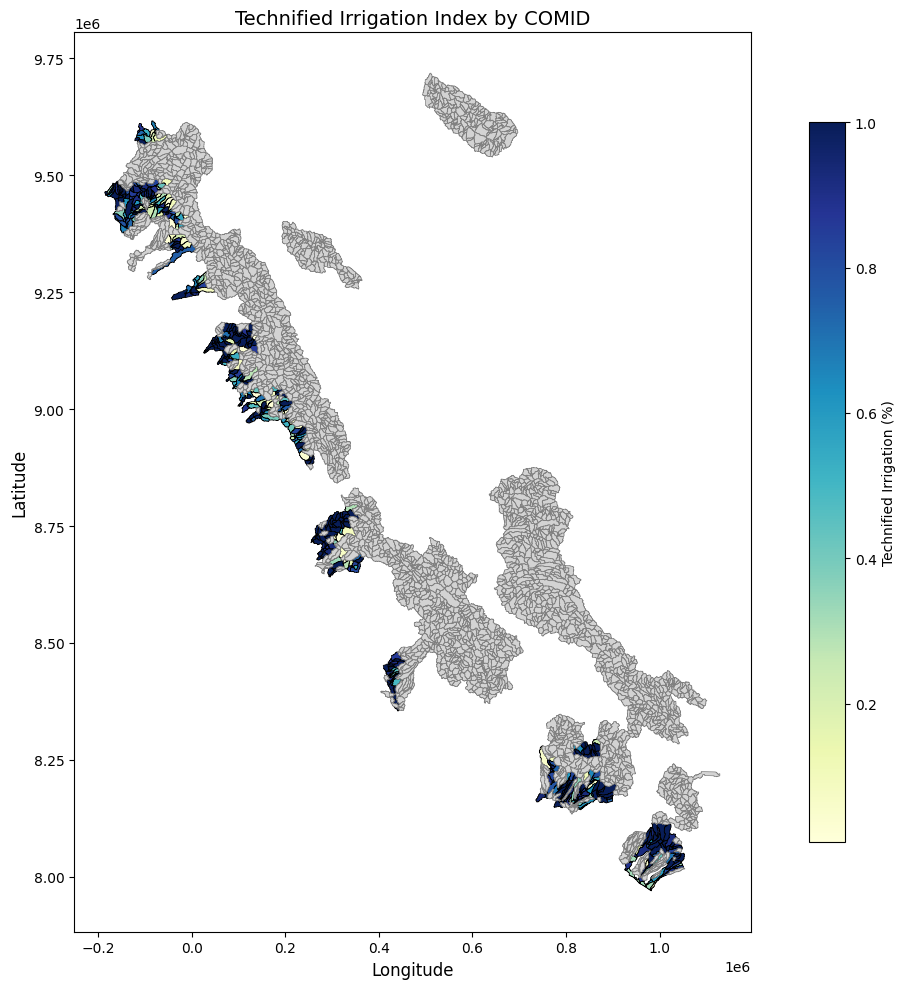

In [7]:
# Plot technified irrigation index
fig, ax = plt.subplots(figsize=(12, 10))

subbasins_gdf.plot(column='Pct_Technified_Irrigation', ax=ax, legend=True, 
                   cmap='YlGnBu', edgecolor='black', linewidth=0.5,
                   missing_kwds={'color': 'lightgrey', 'edgecolor': 'grey', 'label': 'No Data'},
                   legend_kwds={'label': 'Technified Irrigation (%)', 'shrink': 0.8})

ax.set_title('Technified Irrigation Index by COMID', fontsize=14)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
plt.tight_layout()
plt.show()

SQLITE INSERT 

In [15]:
# insert results into the database 
insert_data= subbasins_gdf 
value_column= 'Pct_Technified_Irrigation' 

# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Prepare list of rows to insert
rows_to_insert = []

#use unique scenario IDs
scenario_ids_unique = sorted(set(scenario_ids))

for scn_id in scenario_ids_unique:
    for _, row in insert_data.iterrows():
        comid = row['COMID']
        value = row[value_column]
        rows_to_insert.append((scn_id, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""

In [16]:
# check that min and max values match the expected range based on the Indicators Table 
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, 'Min']
ind_max = indicator_limits.loc[0, 'Max']

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

value_stats = (
    subbasins_gdf['Pct_Technified_Irrigation']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

print("\n=== Values to be inserted (by scenario) ===")
print(value_stats)

# check for duplicates 
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:")
print(df_check[duplicates])

Indicator 401  Min: 0, Max: 1

=== Values to be inserted (by scenario) ===
   index  Pct_Technified_Irrigation
0    min                       0.01
1    max                       1.00
2  count                     572.00
Duplicates in rows_to_insert:
Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [17]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()